# Simple Logistics Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv(r"C:\Users\Suryaprakash\OneDrive\Documents\Python\Logistic_regression\data\simple_loan.csv")

In [3]:
df.head()

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status
0,32,Male,Engineer,Bachelor's,Married,85000,720,Approved
1,45,Female,Teacher,Master's,Single,62000,680,Approved
2,28,Male,Student,High School,Single,25000,590,Denied
3,51,Female,Manager,Bachelor's,Married,105000,780,Approved
4,36,Male,Accountant,Bachelor's,Married,75000,710,Approved


In [4]:
df.head(10)

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status
0,32,Male,Engineer,Bachelor's,Married,85000,720,Approved
1,45,Female,Teacher,Master's,Single,62000,680,Approved
2,28,Male,Student,High School,Single,25000,590,Denied
3,51,Female,Manager,Bachelor's,Married,105000,780,Approved
4,36,Male,Accountant,Bachelor's,Married,75000,710,Approved
5,24,Female,Nurse,Associate's,Single,48000,640,Denied
6,42,Male,Lawyer,Doctoral,Married,120000,790,Approved
7,29,Female,Artist,Bachelor's,Single,38000,620,Denied
8,37,Male,IT,Master's,Married,92000,750,Approved
9,48,Female,Doctor,Doctoral,Married,180000,820,Approved


In [5]:
df.isnull().sum()

age                0
gender             0
occupation         0
education_level    0
marital_status     0
income             0
credit_score       0
loan_status        0
dtype: int64

In [6]:
rows, cols = df.shape
print(f"Rows: {rows}, Columns: {cols}")

Rows: 61, Columns: 8


In [8]:
# check duplicate rows
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")
if dup_count:
    print("\nDuplicate rows (all occurrences):")
    print(df[df.duplicated(keep=False)].sort_values(list(df.columns)).to_string(index=False))
else:
    print("No duplicate rows found.")

# descriptive statistics
print("\nNumeric summary:")
print(df.describe())

print("\nAll-columns summary:")
print(df.describe(include='all').transpose())

print("\nUnique values per column:")
print(df.nunique())

Duplicate rows: 0
No duplicate rows found.

Numeric summary:
             age         income  credit_score
count  61.000000      61.000000     61.000000
mean   37.081967   78983.606557    709.836066
std     8.424755   33772.025802     72.674888
min    24.000000   25000.000000    560.000000
25%    30.000000   52000.000000    650.000000
50%    36.000000   78000.000000    720.000000
75%    43.000000   98000.000000    770.000000
max    55.000000  180000.000000    830.000000

All-columns summary:
                count unique         top freq          mean           std  \
age              61.0    NaN         NaN  NaN     37.081967      8.424755   
gender             61      2        Male   31           NaN           NaN   
occupation         61     38    Engineer    5           NaN           NaN   
education_level    61      5  Bachelor's   23           NaN           NaN   
marital_status     61      2     Married   37           NaN           NaN   
income           61.0    NaN         NaN 

In [9]:
# map target to binary and prepare feature matrix
y = df['loan_status'].map({'Denied': 0, 'Approved': 1})

# select features (exclude original loan_status)
feature_cols = ['age', 'gender', 'occupation', 'education_level', 'marital_status', 'income', 'credit_score']
X = pd.get_dummies(df[feature_cols], drop_first=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (61, 46)
y shape: (61,)


,age,income,credit_score,gender_Male,occupation_Analyst,occupation_Architect,occupation_Artist,occupation_Banker,occupation_Chef,occupation_Consultant,...,occupation_Student,occupation_Stylist,occupation_Teacher,occupation_Veterinarian,occupation_Writer,education_level_Bachelor's,education_level_Doctoral,education_level_High School,education_level_Master's,marital_status_Single
0,32,85000,720,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,45,62000,680,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,True
2,28,25000,590,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,True,False,True
3,51,105000,780,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,36,75000,710,True,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [13]:
# complete encoding before training and testing
feature_cols = ['age', 'gender', 'occupation', 'education_level', 'marital_status', 'income', 'credit_score']
X = pd.get_dummies(df[feature_cols], drop_first=True, dtype=int)
y = df['loan_status'].map({'Denied': 0, 'Approved': 1})

print("Encoded X shape:", X.shape)
print("Encoded feature columns:", X.columns.tolist())
X.head()

Encoded X shape: (61, 46)
Encoded feature columns: ['age', 'income', 'credit_score', 'gender_Male', 'occupation_Analyst', 'occupation_Architect', 'occupation_Artist', 'occupation_Banker', 'occupation_Chef', 'occupation_Consultant', 'occupation_Dentist', 'occupation_Designer', 'occupation_Doctor', 'occupation_Editor', 'occupation_Electrician', 'occupation_Engineer', 'occupation_HR', 'occupation_IT', 'occupation_Lawyer', 'occupation_Manager', 'occupation_Marketing', 'occupation_Musician', 'occupation_Nurse', 'occupation_Pharmacist', 'occupation_Photographer', 'occupation_Pilot', 'occupation_Professor', 'occupation_Programmer', 'occupation_Psychologist', 'occupation_Realtor', 'occupation_Receptionist', 'occupation_Researcher', 'occupation_Sales', 'occupation_Salesman', 'occupation_Server', 'occupation_Software', 'occupation_Student', 'occupation_Stylist', 'occupation_Teacher', 'occupation_Veterinarian', 'occupation_Writer', "education_level_Bachelor's", 'education_level_Doctoral', 'educat

,age,income,credit_score,gender_Male,occupation_Analyst,occupation_Architect,occupation_Artist,occupation_Banker,occupation_Chef,occupation_Consultant,...,occupation_Student,occupation_Stylist,occupation_Teacher,occupation_Veterinarian,occupation_Writer,education_level_Bachelor's,education_level_Doctoral,education_level_High School,education_level_Master's,marital_status_Single
0,32,85000,720,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,45,62000,680,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,1
2,28,25000,590,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,1
3,51,105000,780,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,36,75000,710,1,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


Train accuracy: 1.0
Test accuracy: 0.9230769230769231

Classification report:
              precision    recall  f1-score   support

      Denied       0.75      1.00      0.86         3
    Approved       1.00      0.90      0.95        10

    accuracy                           0.92        13
   macro avg       0.88      0.95      0.90        13
weighted avg       0.94      0.92      0.93        13



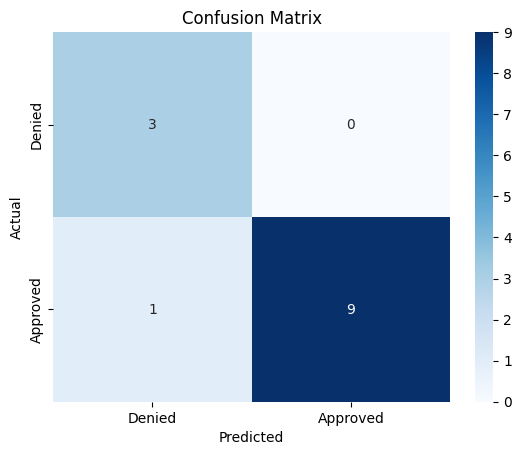

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['Denied', 'Approved']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Denied", "Approved"],
    yticklabels=["Denied", "Approved"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [37]:
from sklearn.metrics import r2_score

feature_means = X.mean()
feature_vars = X.var()
coef_series = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)

print("Feature means:\n", feature_means)
print("\nFeature variances:\n", feature_vars)
print("\nModel coefficients (sorted):\n", coef_series)
print("\nIntercept:", model.intercept_[0])
print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))
print("R^2 score on test set:", r2_score(y_test, y_pred))

Feature means:
 age                               37.081967
income                         78983.606557
credit_score                     709.836066
gender_Male                        0.508197
occupation_Analyst                 0.032787
occupation_Architect               0.032787
occupation_Artist                  0.032787
occupation_Banker                  0.032787
occupation_Chef                    0.032787
occupation_Consultant              0.032787
occupation_Dentist                 0.016393
occupation_Designer                0.032787
occupation_Doctor                  0.032787
occupation_Editor                  0.016393
occupation_Electrician             0.016393
occupation_Engineer                0.081967
occupation_HR                      0.016393
occupation_IT                      0.032787
occupation_Lawyer                  0.032787
occupation_Manager                 0.032787
occupation_Marketing               0.032787
occupation_Musician                0.016393
occupation_Nurse